## Phiên bản được viết bằng Numba

In [671]:
import os
import sys
from pathlib import Path

In [672]:
current_path = Path().resolve()
while current_path.name != "APP-project":
    if current_path.parent == current_path:
        raise FileNotFoundError("❌ Không tìm thấy thư mục gốc 'APP-project'")
    current_path = current_path.parent

os.chdir(current_path)
# print(f"📂 Project root set to: {current_path}")

In [673]:
# !"D:\Download\Downloads\python.exe" -m pip install -r requirements_python311.txt

In [674]:
sys.path.append('Src')
from Src import func as func

import numpy as np
import matplotlib.pyplot as plt

from numpy.lib.stride_tricks import as_strided

import random
import math
import time

from numba import cuda, float32

import warnings
warnings.filterwarnings('ignore')

In [675]:
print("Device name:", cuda.get_current_device().name)

Device name: b'NVIDIA GeForce GTX 1650'


In [676]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Apr_17_19:36:51_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.5, V12.5.40
Build cuda_12.5.r12.5/compiler.34177558_0


In [677]:
!ptxas --version

ptxas: NVIDIA (R) Ptx optimizing assembler
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Apr_17_19:33:34_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.5, V12.5.40
Build cuda_12.5.r12.5/compiler.34177558_0


### Class Conv2D

#### Bổ trợ

In [678]:
# Bước 1: CUDA hóa im2col (mỗi thread lấy 1 patch từ ảnh)
@cuda.jit
def im2col_kernel(input, output, k, s, p, H_out, W_out):
    n, idx = cuda.grid(2)
    if n >= input.shape[0] or idx >= H_out * W_out:
        return

    C = input.shape[3]
    H_in = input.shape[1]
    W_in = input.shape[2]

    h_out = idx // W_out
    w_out = idx % W_out

    for c in range(C):
        for i in range(k):
            h_in = h_out * s + i - p
            for j in range(k):
                w_in = w_out * s + j - p
                val = 0.
                if 0 <= h_in < H_in and 0 <= w_in < W_in:
                    val = input[n, h_in, w_in, c]
                col_idx = (i * k + j) * C + c
                output[n, idx, col_idx] = val


# Bước 2: CUDA hóa col2im (mỗi thread cập nhật 1 pixel trong patch -> accumulate vào ảnh)
@cuda.jit
def col2im_kernel(cols, output, k, s, p, H_out, W_out):
    n, idx = cuda.grid(2)
    if n >= output.shape[0] or idx >= H_out * W_out:
        return

    C = output.shape[3]
    H = output.shape[1]
    W = output.shape[2]

    h_out = idx // W_out
    w_out = idx % W_out

    for c in range(C):
        for i in range(k):
            h = h_out * s + i - p
            for j in range(k):
                w = w_out * s + j - p
                if 0 <= h < H and 0 <= w < W:
                    val = cols[n, idx, (i * k + j) * C + c]
                    cuda.atomic.add(output, (n, h, w, c), val)


# Bước 3: Nhân ma trận với transpose
@cuda.jit
def matmul_T_kernel(A, B_T, C):
    row, col = cuda.grid(2)
    if row < C.shape[0] and col < C.shape[1]:
        tmp = 0.
        for k in range(A.shape[1]):
            tmp += A[row, k] * B_T[k, col]  # B_T là W.T
        C[row, col] = tmp


# Bước 4: Tổng dòng trên ma trận (sum theo batch cho bias)
@cuda.jit
def sum_kernel(mat, out):
    idx = cuda.grid(1)
    if idx < out.shape[0]:
        total = 0.
        for i in range(mat.shape[0]):
            total += mat[i, idx]
        out[idx] = total

#### Class

In [ ]:
@cuda.jit
def add_bias_kernel(out, bias):
    n, h, w = cuda.grid(3)
    N, H, W, F = out.shape
    if n < N and h < H and w < W:
        for f in range(F):
            out[n, h, w, f] += bias[f]

# @cuda.jit
# def matmul_kernel(A, B, C):
#     row, col = cuda.grid(2)
#     if row < C.shape[0] and col < C.shape[1]:
#         tmp = 0.
#         for k in range(A.shape[1]):
#             if not math.isnan(tmp) and not math.isinf(tmp) and abs(tmp) < 1e8:
#                 C[row, col] = tmp
#             else:
#                 C[row, col] = 0.0

@cuda.jit
def matmul_kernel(A, B, C):
    row, col = cuda.grid(2)
    if row < C.shape[0] and col < C.shape[1]:
        tmp = 0.
        for k in range(A.shape[1]):
            tmp += A[row, k] * B[k, col]
        if not math.isnan(tmp) and not math.isinf(tmp) and abs(tmp) < 1e8:
            C[row, col] = tmp
        else:
            C[row, col] = 0.0

class Conv2D_CUDA:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        limit = 0.1
        self.kernels = np.random.uniform(
            -limit, limit, (out_channels, kernel_size * kernel_size * in_channels)
        ).astype(np.float32)
        self.biases = np.random.uniform(-limit, limit, out_channels).astype(np.float32)
        self.v_kernels = np.zeros_like(self.kernels)
        self.v_biases = np.zeros_like(self.biases)

    def forward(self, input_data):
        self.input_data = input_data
        N, H, W, C = input_data.shape
        k, s, p = self.kernel_size, self.stride, self.padding
        H_out = (H + 2 * p - k) // s + 1
        W_out = (W + 2 * p - k) // s + 1
        L, K = H_out * W_out, k * k * C
        F = self.out_channels

        # ✅ STEP 1: PADDING TRƯỚC
        input_padded = np.pad(input_data, ((0, 0), (p, p), (p, p), (0, 0)), mode='constant')
        d_input = cuda.to_device(np.ascontiguousarray(input_padded.astype(np.float32)))

        d_cols = cuda.device_array((N, L, K), dtype=np.float32)

        # im2col
        block = (16, 16)
        grid = (math.ceil(N / block[0]), math.ceil(L / block[1]))
        im2col_kernel[grid, block](d_input, d_cols, k, s, 0, H_out, W_out)  # padding=0 vì đã pad rồi

        # matmul
        A = d_cols.reshape(N * L, K)
        d_kernels_T = cuda.to_device(self.kernels.T.astype(np.float32))
        d_out = cuda.device_array((N * L, F), dtype=np.float32)
        block_mat = (32, 4)
        grid_mat = (math.ceil((N * L) / block_mat[0]), math.ceil(F / block_mat[1]))
        matmul_kernel[grid_mat, block_mat](A, d_kernels_T, d_out)

        # reshape d_out to 4D
        d_out_4d = d_out.reshape(N, H_out, W_out, F)

        # add bias
        block_bias = (8, 8, 8)
        grid_bias = (
            math.ceil(N / block_bias[0]),
            math.ceil(H_out / block_bias[1]),
            math.ceil(W_out / block_bias[2])
        )
        d_bias = cuda.to_device(self.biases)
        add_bias_kernel[grid_bias, block_bias](d_out_4d, d_bias)

        result = d_out_4d.copy_to_host()
        if np.isnan(result).any() or np.isinf(result).any():
            print("⚠️ Conv2D output contains NaN/Inf!")

        cuda.synchronize()
        return result

    def backward(self, grad_output):
        N, H_out, W_out, F = grad_output.shape
        k, s, p = self.kernel_size, self.stride, self.padding
        C = self.in_channels
        L = H_out * W_out
        K = k * k * C

        # --- B1: reshape grad_output và đẩy lên GPU ---
        grad_output_reshaped = grad_output.reshape(N * L, F).astype(np.float32)
        d_grad_output = cuda.to_device(grad_output_reshaped)  # shape (N*L, F)

        # --- B2: im2col lại từ input để tính grad_kernel ---
        input_np = self.input_data.astype(np.float32)
        d_input = cuda.to_device(np.ascontiguousarray(input_np))
        d_cols = cuda.device_array((N, L, K), dtype=np.float32)

        block = (32, 4)
        grid = (math.ceil(N / block[0]), math.ceil(L / block[1]))
        im2col_kernel[grid, block](d_input, d_cols, k, s, p, H_out, W_out)

        # --- B3: grad_kernels = grad_output.T @ cols ---
        # A = (F, N*L), B = (N*L, K) → C = (F, K)
        A_host = grad_output_reshaped.T.copy()              # (F, N*L)
        B_host = d_cols.reshape(N * L, K).copy_to_host()    # (N*L, K)

        d_A = cuda.to_device(A_host)
        d_B = cuda.to_device(np.ascontiguousarray(B_host))
        d_grad_kernels = cuda.device_array((F, K), dtype=np.float32)

        grid_mat = (math.ceil(F / block[0]), math.ceil(K / block[1]))
        matmul_kernel[grid_mat, block](d_A, d_B, d_grad_kernels)

        self.grad_kernels = d_grad_kernels.copy_to_host()

        # --- B4: grad_bias = sum theo batch ---
        d_grad_biases = cuda.device_array((F,), dtype=np.float32)
        sum_kernel[(math.ceil(F / 256),), (256,)](d_grad_output, d_grad_biases)
        self.grad_biases = d_grad_biases.copy_to_host()

        # --- B5: grad_input = grad_output @ kernels.T ---
        # A = (N*L, F), B = (F, K) → C = (N*L, K)
        d_kernels = cuda.to_device(np.ascontiguousarray(self.kernels))
        d_grad_cols = cuda.device_array((N * L, K), dtype=np.float32)

        grid_in = (math.ceil((N * L) / block[0]), math.ceil(K / block[1]))
        matmul_kernel[grid_in, block](d_grad_output, d_kernels, d_grad_cols)

        d_grad_cols_reshaped = d_grad_cols.reshape(N, L, K)
        d_grad_input = cuda.device_array_like(self.input_data)

        grid_col2im = (math.ceil(N / 16), math.ceil(L / 16))
        block_col2im = (16, 16)
        col2im_kernel[grid_col2im, block_col2im](
            d_grad_cols_reshaped, d_grad_input, k, s, p, H_out, W_out
        )

        return d_grad_input.copy_to_host()

    def step(self, lr, momentum):
        self.v_kernels = momentum * self.v_kernels - lr * self.grad_kernels
        self.v_biases = momentum * self.v_biases - lr * self.grad_biases
        self.kernels += self.v_kernels
        self.biases += self.v_biases

        # np.clip(self.kernels, -1, 1, out=self.kernels)
        # np.clip(self.biases, -1, 1, out=self.biases)

        print("👉 Kernel stats - mean:", self.kernels.mean(), "std:", self.kernels.std())


#### Test

In [680]:
def preprocess_cifar10_data():
    X_train, y_train, X_test, y_test = func.load_cifar10_data()

    # Chuyển từ (N, C, H, W) -> (N, H, W, C) và chuẩn hóa về [0, 1]
    X_train = X_train.transpose(0, 2, 3, 1).astype(np.float32) / 255.0
    X_test = X_test.transpose(0, 2, 3, 1).astype(np.float32) / 255.0

    # One-hot encoding cho nhãn
    num_classes = 10
    y_train_onehot = np.eye(num_classes)[y_train]
    y_test_onehot = np.eye(num_classes)[y_test]

    return X_train, y_train_onehot, X_test, y_test_onehot

In [681]:
X_train, y_train_onehot, X_test, y_test_onehot = preprocess_cifar10_data()

# in shape của dữ liệu
print(f"X_train shape: {X_train.shape}")
print(f"y_train_onehot shape: {y_train_onehot.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test_onehot shape: {y_test_onehot.shape}")

X_train shape: (50000, 32, 32, 3)
y_train_onehot shape: (50000, 10)
X_test shape: (10000, 32, 32, 3)
y_test_onehot shape: (10000, 10)


In [682]:
# # Chọn một batch nhỏ để test
# N = 4  # batch size nhỏ để kiểm thử
# x_batch = X_train[:N]  # shape: (4, 16, 16, 3)
# y_batch = y_train_onehot[:N]  # shape: (4, 10)

# # Tạo lớp Conv2D_CUDA
# conv = Conv2D_CUDA(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1)

# # Forward
# out = conv.forward(x_batch)  # shape expected: (4, 16, 16, 8)
# print("Forward output shape:", out.shape)

# # Tạo gradient giả lập từ loss layer (giả sử đang dùng MSE hoặc cross-entropy softmax)
# # => output_grad = cùng shape với out
# grad_out = np.random.randn(*out.shape).astype(np.float32)

# # Backward
# dx = conv.backward(grad_out)  # shape expected: (4, 16, 16, 3)
# print("Backward output shape (same as input):", dx.shape)

# # Step
# conv.step(lr=0.001, momentum=0.9)

# # Kiểm tra sau khi step: kernel có thay đổi không?
# print("Kernel mean after step:", np.mean(conv.kernels))

### Class ReLU

#### Forward

In [683]:
@cuda.jit
def relu_forward_kernel_opt_v2(input_tensor, output_tensor, mask):
    w, h = cuda.grid(2)
    c = cuda.blockIdx.z % input_tensor.shape[3]
    n = cuda.blockIdx.z // input_tensor.shape[3]

    if n < input_tensor.shape[0] and h < input_tensor.shape[1] and w < input_tensor.shape[2]:
        val = input_tensor[n, h, w, c]
        output_tensor[n, h, w, c] = max(val, 0)
        mask[n, h, w, c] = 1 if val > 0 else 0

#### Backward

In [684]:
@cuda.jit
def relu_backward_kernel_opt_v2(grad_output, mask, grad_input):
    w, h = cuda.grid(2)
    c = cuda.blockIdx.z % grad_output.shape[3]
    n = cuda.blockIdx.z // grad_output.shape[3]

    if n < grad_output.shape[0] and h < grad_output.shape[1] and w < grad_output.shape[2]:
        grad_input[n, h, w, c] = grad_output[n, h, w, c] if mask[n, h, w, c] > 0 else 0

#### Class ReLU_CUDA

In [685]:
class ReLU_CUDA:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        N, H, W, C = x.shape
        self.mask = np.zeros_like(x, dtype=np.float32)
        output = np.zeros_like(x, dtype=np.float32)

        d_input = cuda.to_device(np.ascontiguousarray(x))
        d_output = cuda.device_array_like(output)
        d_mask = cuda.device_array_like(self.mask)

        block = (32, 4)
        grid = (
            math.ceil(W / block[0]),
            math.ceil(H / block[1]),
            N * C
        )

        relu_forward_kernel_opt_v2[grid, block](d_input, d_output, d_mask)
        self.mask = d_mask.copy_to_host()  # Nếu backward cần

        return d_output.copy_to_host()

    def backward(self, grad_output):
        N, H, W, C = grad_output.shape
        grad_input = np.zeros_like(grad_output, dtype=np.float32)

        d_grad_output = cuda.to_device(np.ascontiguousarray(grad_output))
        d_mask = cuda.to_device(np.ascontiguousarray(self.mask))
        d_grad_input = cuda.device_array_like(grad_input)

        block = (32, 4)
        grid = (
            math.ceil(W / block[0]),
            math.ceil(H / block[1]),
            N * C
        )

        relu_backward_kernel_opt_v2[grid, block](d_grad_output, d_mask, d_grad_input)
        return d_grad_input.copy_to_host()

#### Test

In [686]:
# # Khởi tạo lớp ReLU_CUDA
# relu = ReLU_CUDA()

# # Forward qua conv
# out_conv = conv.forward(x_batch)

# # Forward qua ReLU
# out_relu = relu.forward(out_conv)
# print("ReLU Forward output shape:", out_relu.shape)

# # Gradient giả lập từ lớp trên (cùng shape)
# grad_relu = np.random.randn(*out_relu.shape).astype(np.float32)

# # Backward ReLU
# grad_conv_out = relu.backward(grad_relu)

# # Backward Conv
# dx = conv.backward(grad_conv_out)
# print("Final backward shape (dL/dInput):", dx.shape)

# # Update Conv weights
# conv.step(lr=0.001, momentum=0.9)

# # Xem thử kernel thay đổi
# print("Kernel mean after conv+ReLU+backward+step:", np.mean(conv.kernels))

### Class MaxPool2D

#### Forward

In [687]:
@cuda.jit
def maxpool2d_forward_kernel_opt(input_tensor, output_tensor, indices, ksize, stride):
    n = cuda.blockIdx.z // input_tensor.shape[3]
    c = cuda.blockIdx.z % input_tensor.shape[3]
    h_out = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y
    w_out = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x

    H, W = input_tensor.shape[1], input_tensor.shape[2]
    H_out = output_tensor.shape[1]
    W_out = output_tensor.shape[2]

    if n < input_tensor.shape[0] and h_out < H_out and w_out < W_out:
        h_start = h_out * stride
        w_start = w_out * stride

        max_val = -1e10
        max_idx = 0
        for i in range(ksize):
            for j in range(ksize):
                h = h_start + i
                w = w_start + j
                if h < H and w < W:
                    val = input_tensor[n, h, w, c]
                    if val > max_val:
                        max_val = val
                        max_idx = i * ksize + j

        output_tensor[n, h_out, w_out, c] = max_val
        indices[n, h_out, w_out, c] = max_idx

#### Backward

In [688]:
@cuda.jit
def maxpool2d_backward_kernel_opt(grad_output, indices, grad_input, ksize, stride):
    n = cuda.blockIdx.z // grad_input.shape[3]
    c = cuda.blockIdx.z % grad_input.shape[3]
    h_out = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y
    w_out = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x

    H, W = grad_input.shape[1], grad_input.shape[2]
    H_out = grad_output.shape[1]
    W_out = grad_output.shape[2]

    if n < grad_input.shape[0] and h_out < H_out and w_out < W_out:
        max_idx = int(indices[n, h_out, w_out, c])
        i = max_idx // ksize
        j = max_idx % ksize
        h = h_out * stride + i
        w = w_out * stride + j
        if h < H and w < W:
            grad_input[n, h, w, c] = grad_output[n, h_out, w_out, c]

#### Class

In [689]:
class MaxPool2D_CUDA:
    def __init__(self, kernel_size=2, stride=2):
        self.kernel_size = kernel_size
        self.stride = stride
        self.d_indices = None  # lưu trên GPU
        self.input_shape = None

    def forward(self, x):
        self.input_shape = x.shape
        N, H, W, C = x.shape
        k, s = self.kernel_size, self.stride
        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1

        output = np.zeros((N, H_out, W_out, C), dtype=np.float32)
        d_input = cuda.to_device(np.ascontiguousarray(x.astype(np.float32)))
        d_output = cuda.device_array_like(output)
        d_indices = cuda.device_array(output.shape, dtype=np.int16)

        threads_per_block = (32, 4)
        grid_size = (
            math.ceil(W_out / threads_per_block[0]),
            math.ceil(H_out / threads_per_block[1]),
            N * C
        )

        maxpool2d_forward_kernel_opt[grid_size, threads_per_block](
            d_input, d_output, d_indices, k, s
        )

        self.d_indices = d_indices  # giữ lại trên GPU
        return d_output.copy_to_host()

    def backward(self, grad_output):
        N, H, W, C = self.input_shape
        k, s = self.kernel_size, self.stride
        H_out, W_out = grad_output.shape[1:3]

        d_grad_output = cuda.to_device(np.ascontiguousarray(grad_output.astype(np.float32)))
        d_grad_input = cuda.device_array((N, H, W, C), dtype=np.float32)

        threads_per_block = (32, 4)
        grid_size = (
            math.ceil(W_out / threads_per_block[0]),
            math.ceil(H_out / threads_per_block[1]),
            N * C
        )

        maxpool2d_backward_kernel_opt[grid_size, threads_per_block](
            d_grad_output, self.d_indices, d_grad_input, k, s
        )

        return d_grad_input.copy_to_host()

#### Test

In [690]:
# # Khởi tạo lớp MaxPool2D_CUDA
# pool = MaxPool2D_CUDA(kernel_size=2, stride=2)

# # Forward qua MaxPool
# out_pool = pool.forward(out_relu)
# print("MaxPool Forward output shape:", out_pool.shape)

# # Gradient giả lập từ lớp trên (giả sử softmax, loss, ...)
# grad_pool = np.random.randn(*out_pool.shape).astype(np.float32)

# # Backward MaxPool
# grad_relu_out = pool.backward(grad_pool)

# # Backward ReLU
# grad_conv_out = relu.backward(grad_relu_out)

# # Backward Conv
# dx = conv.backward(grad_conv_out)
# print("Final backward shape after MaxPool-ReLU-Conv:", dx.shape)

# # Cập nhật trọng số Conv
# conv.step(lr=0.001, momentum=0.9)

# # Kiểm tra thay đổi kernel
# print("Kernel mean after full block backward + step:", np.mean(conv.kernels))

### Conv Block

In [691]:
class ConvBlock_CUDA:
    def __init__(self, in_channels, out_channels, num_convs=2, padding=1, stride=1):
        self.convs = []
        self.relus = []

        for _ in range(num_convs):
            conv = Conv2D_CUDA(in_channels, out_channels, kernel_size=3, padding=padding, stride=stride)
            relu = ReLU_CUDA()
            self.convs.append(conv)
            self.relus.append(relu)
            in_channels = out_channels  # chuẩn bị cho conv tiếp theo

        self.pool = MaxPool2D_CUDA(kernel_size=2, stride=2)

    def forward(self, input):
        x = input
        for conv, relu in zip(self.convs, self.relus):
            x = conv.forward(x)
            x = relu.forward(x)
        x = self.pool.forward(x)
        return x

    def backward(self, d_out):
        d_out = self.pool.backward(d_out)
        for conv, relu in zip(reversed(self.convs), reversed(self.relus)):
            d_out = relu.backward(d_out)
            d_out = conv.backward(d_out)
        return d_out

    def step(self, learning_rate, momentum=0.9):
        for conv in self.convs:
            conv.step(learning_rate, momentum)

### Class Flatten

In [692]:
class Flatten_CUDA:
    def __init__(self):
        self.input_shape = None

    def forward(self, input):
        # Lưu lại shape ban đầu (N, H, W, C)
        self.input_shape = input.shape
        return input.reshape(input.shape[0], -1)  # giữ batch dim

    def backward(self, grad_output):
        return grad_output.reshape(self.input_shape)

### Class Fully Connected Layer

#### Forward

In [693]:
@cuda.jit
def fc_forward_kernel(input_vec, weights, bias, output):
    i = cuda.grid(1)
    if i < weights.shape[1]:  # output dim
        tmp = 0.
        for j in range(weights.shape[0]):  # input dim
            tmp += input_vec[j] * weights[j, i]
        output[i] = tmp + bias[i]

#### Backward

In [694]:
@cuda.jit
def fc_backward_kernel(grad_output, weights, grad_input):
    i = cuda.grid(1)
    if i < weights.shape[0]:  # input dim
        tmp = 0.
        for j in range(weights.shape[1]):
            tmp += grad_output[j] * weights[i, j]
        grad_input[i] = tmp

#### Class

In [695]:
@cuda.jit
def add_bias_fc_kernel(mat, bias, out):
    row, col = cuda.grid(2)
    if row < mat.shape[0] and col < mat.shape[1]:
        out[row, col] = mat[row, col] + bias[col]

@cuda.jit
def matmul_T_kernel_fc(A, B, C):
    row, col = cuda.grid(2)
    if row < C.shape[0] and col < C.shape[1]:
        tmp = 0.
        for k in range(A.shape[0]):
            tmp += A[k, row] * B[k, col]  # A.T @ B
        C[row, col] = tmp

class FullyConnected_CUDA:
    def __init__(self, in_dim, out_dim):
        limit = 0.01
        self.W = np.random.uniform(-limit, limit, (in_dim, out_dim)).astype(np.float32)
        self.b = np.random.uniform(-limit, limit, out_dim).astype(np.float32)
        self.v_W = np.zeros_like(self.W)
        self.v_b = np.zeros_like(self.b)

    def forward(self, x):
        self.input = x.astype(np.float32)
        N, in_dim = self.input.shape
        out_dim = self.W.shape[1]

        d_input = cuda.to_device(self.input)
        d_W = cuda.to_device(self.W)
        d_mat = cuda.device_array((N, out_dim), dtype=np.float32)

        threads = (32, 4)
        grid = (math.ceil(N / threads[0]), math.ceil(out_dim / threads[1]))
        matmul_kernel[grid, threads](d_input, d_W, d_mat)

        d_bias = cuda.to_device(self.b)
        d_out = cuda.device_array((N, out_dim), dtype=np.float32)
        add_bias_fc_kernel[grid, threads](d_mat, d_bias, d_out)

        return d_out.copy_to_host()

    def backward(self, grad_output):
        grad_output = grad_output.astype(np.float32)
        N, out_dim = grad_output.shape
        in_dim = self.W.shape[0]

        d_input = cuda.to_device(self.input)
        d_grad_output = cuda.to_device(grad_output)

        d_grad_W = cuda.device_array((in_dim, out_dim), dtype=np.float32)
        threads = (32, 4)
        grid = (math.ceil(in_dim / threads[0]), math.ceil(out_dim / threads[1]))
        matmul_T_kernel_fc[grid, threads](d_input, d_grad_output, d_grad_W)
        self.grad_W = d_grad_W.copy_to_host()

        d_grad_b = cuda.device_array(out_dim, dtype=np.float32)
        sum_kernel[(math.ceil(out_dim / 256),), (256,)](d_grad_output, d_grad_b)
        self.grad_b = d_grad_b.copy_to_host()

        d_W_T = cuda.to_device(self.W.T)
        d_grad_input = cuda.device_array((N, in_dim), dtype=np.float32)
        grid_in = (math.ceil(N / threads[0]), math.ceil(in_dim / threads[1]))
        matmul_kernel[grid_in, threads](d_grad_output, d_W_T, d_grad_input)

        return d_grad_input.copy_to_host()

    def step(self, learning_rate, momentum=0.9):
        self.v_W = momentum * self.v_W - learning_rate * self.grad_W
        self.v_b = momentum * self.v_b - learning_rate * self.grad_b
        self.W += self.v_W
        self.b += self.v_b

# class FullyConnected_CUDA:
#     def __init__(self, in_dim, out_dim):
#         limit = 0.01
#         self.W = np.random.uniform(-limit, limit, (in_dim, out_dim)).astype(np.float32)
#         self.b = np.random.uniform(-limit, limit, out_dim).astype(np.float32)
#         self.v_W = np.zeros_like(self.W)
#         self.v_b = np.zeros_like(self.b)

#     def forward(self, x):
#         # x: shape (in_dim,)
#         self.input = x.astype(np.float32)
#         return np.dot(self.input, self.W) + self.b

#     def backward(self, grad_output):
#         self.grad_W = np.outer(self.input, grad_output)
#         self.grad_b = grad_output.reshape(-1)  # Đảm bảo 1D shape
#         grad_input = np.dot(grad_output, self.W.T)
#         return grad_input

#     def step(self, learning_rate, momentum=0.9):
#         self.v_W = momentum * self.v_W - learning_rate * self.grad_W
#         self.v_b = momentum * self.v_b - learning_rate * self.grad_b
#         self.W += self.v_W
#         self.b += self.v_b

#### Test

In [696]:
# # Flatten
# flatten = Flatten_CUDA()
# x_flat = flatten.forward(out_pool)
# print("✅ Flatten output shape:", x_flat.shape)  # (N, D)

# # Fully Connected
# fc = FullyConnected_CUDA(in_dim=x_flat.shape[1], out_dim=10)
# out_fc = fc.forward(x_flat)
# print("✅ FC Forward output shape:", out_fc.shape)  # (N, 10)

# # Giả lập gradient từ loss (cùng shape với out_fc)
# grad_fc = np.random.randn(*out_fc.shape).astype(np.float32)

# # Backward FC → Flatten
# grad_flat = fc.backward(grad_fc)
# fc.step(learning_rate=0.001, momentum=0.9)
# dx_pool = flatten.backward(grad_flat)

# # Backward Pool → ReLU → Conv (tiếp tục phần trước)
# grad_relu_out = pool.backward(dx_pool)
# grad_conv_out = relu.backward(grad_relu_out)
# dx = conv.backward(grad_conv_out)
# conv.step(lr=0.001, momentum=0.9)

# # In kết quả cuối
# print("✅ Final dx shape:", dx.shape)
# print("✅ Conv kernel mean after update:", np.mean(conv.kernels))
# print("✅ FC weight mean after update:", np.mean(fc.W))

### Class ReLU cho vector

#### Forward

In [697]:
@cuda.jit
def relu_vector_forward_kernel_2d(x, y, mask, D):
    n = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y
    d = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x

    if n < x.shape[0] and d < D:
        val = x[n, d]
        if val > 0:
            y[n, d] = val
            mask[n, d] = 1
        else:
            y[n, d] = 0
            mask[n, d] = 0

#### Backward

In [698]:
@cuda.jit
def relu_vector_backward_kernel_2d(grad_output, mask, grad_input, D):
    n = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y
    d = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x

    if n < grad_output.shape[0] and d < D:
        grad_input[n, d] = grad_output[n, d] * mask[n, d]

#### Class

In [699]:
class ReLUVector_CUDA:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        x = np.ascontiguousarray(x.astype(np.float32))
        y = np.zeros_like(x, dtype=np.float32)
        self.mask = np.zeros_like(x, dtype=np.float32)

        N, D = x.shape
        d_x = cuda.to_device(x)
        d_y = cuda.device_array_like(y)
        d_mask = cuda.device_array_like(self.mask)

        threads_per_block = (32, 4)
        grid_size = (
            math.ceil(D / threads_per_block[0]),
            math.ceil(N / threads_per_block[1])
        )

        relu_vector_forward_kernel_2d[grid_size, threads_per_block](d_x, d_y, d_mask, D)
        cuda.synchronize()

        self.mask = d_mask.copy_to_host()
        return d_y.copy_to_host()

    def backward(self, grad_output):
        grad_output = np.ascontiguousarray(grad_output.astype(np.float32))
        grad_input = np.zeros_like(grad_output, dtype=np.float32)

        N, D = grad_output.shape
        d_grad_output = cuda.to_device(grad_output)
        d_mask = cuda.to_device(self.mask)
        d_grad_input = cuda.device_array_like(grad_input)

        threads_per_block = (32, 4)
        grid_size = (
            math.ceil(D / threads_per_block[0]),
            math.ceil(N / threads_per_block[1])
        )

        relu_vector_backward_kernel_2d[grid_size, threads_per_block](d_grad_output, d_mask, d_grad_input, D)
        cuda.synchronize()

        return d_grad_input.copy_to_host()

#### Test

In [700]:
# # ReLU sau FullyConnected
# relu_vec = ReLUVector_CUDA()
# out_relu_vec = relu_vec.forward(out_fc)
# print("✅ ReLUVector Forward output shape:", out_relu_vec.shape)  # (N, 10)

# # Giả lập gradient từ loss layer (VD: softmax loss)
# grad_relu_vec = np.random.randn(*out_relu_vec.shape).astype(np.float32)

# # Backward ReLUVector
# grad_fc_out = relu_vec.backward(grad_relu_vec)

# # Backward FC
# grad_flat = fc.backward(grad_fc_out)
# fc.step(learning_rate=0.001, momentum=0.9)

# # Backward Flatten → Pool → ReLU → Conv
# dx_pool = flatten.backward(grad_flat)
# grad_relu_out = pool.backward(dx_pool)
# grad_conv_out = relu.backward(grad_relu_out)
# dx = conv.backward(grad_conv_out)
# conv.step(lr=0.001, momentum=0.9)

# # In kết quả cuối
# print("✅ Final dx shape:", dx.shape)
# print("✅ Conv kernel mean after update:", np.mean(conv.kernels))
# print("✅ FC weight mean after update:", np.mean(fc.W))

### Class Softmax + CrossEntropyLoss

In [701]:
@cuda.jit
def softmax_forward_kernel(x, out, max_per_row, sum_exp_per_row, D):
    n = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y
    d = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x

    if n < x.shape[0] and d < D:
        val = x[n, d] - max_per_row[n]
        # Clip giá trị đầu vào exp để tránh overflow và precision loss
        if val < 80.0 and val > -80.0:
            num = math.exp(val)
        else:
            num = 0.0
        denom = sum_exp_per_row[n] if sum_exp_per_row[n] > 1e-6 else 1e-6
        out[n, d] = num / denom


class Softmax_CUDA:
    def __init__(self):
        self.output = None
        self.input = None

    def forward(self, x):
        self.input = np.ascontiguousarray(x.astype(np.float32))  # (N, D)
        N, D = self.input.shape

        # Tính max theo hàng để tránh overflow
        x_max = np.max(self.input, axis=1, keepdims=True)  # (N, 1)
        x_stable = self.input - x_max
        exps = np.exp(x_stable)
        sum_exp = np.sum(exps, axis=1, keepdims=True)  # (N, 1)
        sum_exp = np.clip(sum_exp, 1e-6, np.inf)  # Tránh chia 0

        # Copy sang device
        d_x = cuda.to_device(self.input)
        d_out = cuda.device_array_like(self.input)
        d_max = cuda.to_device(x_max.flatten())
        d_sum = cuda.to_device(sum_exp.flatten())

        threads_per_block = (32, 4)
        grid_size = (
            math.ceil(D / threads_per_block[0]),
            math.ceil(N / threads_per_block[1])
        )

        # Chạy kernel
        softmax_forward_kernel[grid_size, threads_per_block](
            d_x, d_out, d_max, d_sum, D
        )
        cuda.synchronize()

        self.output = d_out.copy_to_host()
        return self.output


class CrossEntropyLoss_CUDA:
    def __init__(self):
        self.pred_probs = None
        self.target_onehot = None

    def forward(self, pred_probs, target_onehot):
        pred_probs = np.clip(pred_probs, 1e-12, 1.0)
        self.pred_probs = pred_probs
        self.target_onehot = target_onehot.astype(np.float32)
        return -np.sum(self.target_onehot * np.log(pred_probs)) / pred_probs.shape[0]

    def backward(self):
        return (self.pred_probs - self.target_onehot) / self.pred_probs.shape[0]

#### Test

In [702]:
# # Softmax và Loss
# softmax = Softmax_CUDA()
# ce_loss = CrossEntropyLoss_CUDA()

# # Forward Softmax
# probs = softmax.forward(out_relu_vec)
# print("✅ Softmax output shape:", probs.shape)  # (N, 10)

# # Forward Loss (y_batch phải là one-hot)
# loss_val = ce_loss.forward(probs, y_batch)
# print("✅ CrossEntropy Loss:", loss_val)

# # Backward Loss
# grad_softmax = ce_loss.backward()

# # Backward qua ReLUVector → FC → Conv...
# grad_fc_out = relu_vec.backward(grad_softmax)
# grad_flat = fc.backward(grad_fc_out)
# fc.step(learning_rate=0.001, momentum=0.9)

# dx_pool = flatten.backward(grad_flat)
# grad_relu_out = pool.backward(dx_pool)
# grad_conv_out = relu.backward(grad_relu_out)
# dx = conv.backward(grad_conv_out)
# conv.step(lr=0.001, momentum=0.9)

# # Output kết quả cuối cùng
# print("✅ Final dx shape:", dx.shape)
# print("✅ Conv kernel mean after update:", np.mean(conv.kernels))
# print("✅ FC weight mean after update:", np.mean(fc.W))

### Class Cấu Trúc

In [703]:
class SimpleCNN_CUDA:
    def __init__(self):
        self.block1 = ConvBlock_CUDA(3, 64, num_convs=2, padding=1)
        self.block2 = ConvBlock_CUDA(64, 128, num_convs=2, padding=1)
        self.block3 = ConvBlock_CUDA(128, 256, num_convs=2, padding=1)

        self.flatten = Flatten_CUDA()
        self.fc1 = FullyConnected_CUDA(256 * 4 * 4, 512)
        self.relu_fc1 = ReLUVector_CUDA()
        self.fc2 = FullyConnected_CUDA(512, 10)
        self.softmax = Softmax_CUDA()

### Train

In [704]:
def train_cuda(model, train_data, train_labels, epochs=10, learning_rate=0.01,
               mb_size=16, momentum=0.9, lr_decay_factor=0.5,
               log_filename="training_log_cuda.csv", detail_log_filename="details_log_cuda.csv"):

    np.random.seed(0)
    best_train_acc = 0
    plateau_count = 0
    patience = 2

    loss_fn = CrossEntropyLoss_CUDA()
    n_samples = train_data.shape[0]
    indices = np.arange(n_samples)

    for epoch in range(epochs):
        start_epoch = time.time()
        total_loss = 0.0
        correct = 0

        conv2d_time = relu_time = maxpool_time = flatten_time = fc_time = softmax_time = 0.0

        np.random.shuffle(indices)
        train_data_shuffled = train_data[indices]
        train_labels_shuffled = train_labels[indices]

        full_batch_count = n_samples // mb_size
        for i in range(full_batch_count):
            start = i * mb_size
            end = start + mb_size
            X_batch = train_data_shuffled[start:end]
            y_batch = train_labels_shuffled[start:end]

            for x_idx, (x, target) in enumerate(zip(X_batch, y_batch)):
                x = x[None, ...]
                target = target[None, ...]

                print(f"\n📌 Sample {i * mb_size + x_idx}")
                # print("- Input mean/std:", x.mean(), x.std())

                out = x
                for conv, relu in zip(model.block1.convs, model.block1.relus):
                    t0 = time.time(); out = conv.forward(out); t1 = time.time(); conv2d_time += t1 - t0
                    print(f"🧪 Conv output (before ReLU): mean={out.mean():.6f}, std={out.std():.6f}, min={out.min():.6f}, max={out.max():.6f}")
                    # 🧪 In debug sau Conv
                    # print("   🔬 Conv out shape:", out.shape)
                    # print("   🔬 Conv out mean/std:", out.mean(), out.std())
                    # print("   🔬 Conv out has NaN?", np.isnan(out).any())

                    t0 = time.time(); out = relu.forward(out); t1 = time.time(); relu_time += t1 - t0
                    # print("🔍 Block1 relu output:", out.mean(), out.std())
                print("🔍 After Block1:", out.mean(), out.std(), "| min:", out.min(), "| max:", out.max())

                t0 = time.time(); out = model.block1.pool.forward(out); t1 = time.time(); maxpool_time += t1 - t0

                for conv, relu in zip(model.block2.convs, model.block2.relus):
                    t0 = time.time(); out = conv.forward(out); t1 = time.time(); conv2d_time += t1 - t0
                    print(f"🧪 Conv output (before ReLU): mean={out.mean():.6f}, std={out.std():.6f}, min={out.min():.6f}, max={out.max():.6f}")
                    # 🧪 In debug sau Conv
                    # print("   🔬 Conv out shape:", out.shape)
                    # print("   🔬 Conv out mean/std:", out.mean(), out.std())
                    # print("   🔬 Conv out has NaN?", np.isnan(out).any())

                    t0 = time.time(); out = relu.forward(out); t1 = time.time(); relu_time += t1 - t0
                    # print("🔍 Block2 relu output:", out.mean(), out.std())
                print("🔍 After Block2:", out.mean(), out.std(), "| min:", out.min(), "| max:", out.max())

                t0 = time.time(); out = model.block2.pool.forward(out); t1 = time.time(); maxpool_time += t1 - t0

                for conv, relu in zip(model.block3.convs, model.block3.relus):
                    t0 = time.time(); out = conv.forward(out); t1 = time.time(); conv2d_time += t1 - t0
                    print(f"🧪 Conv output (before ReLU): mean={out.mean():.6f}, std={out.std():.6f}, min={out.min():.6f}, max={out.max():.6f}")
                    # 🧪 In debug sau Conv
                    # print("   🔬 Conv out shape:", out.shape)
                    # print("   🔬 Conv out mean/std:", out.mean(), out.std())
                    # print("   🔬 Conv out has NaN?", np.isnan(out).any())
                    
                    t0 = time.time(); out = relu.forward(out); t1 = time.time(); relu_time += t1 - t0
                    # print("🔍 Block3 relu output:", out.mean(), out.std())
                print("🔍 After Block3:", out.mean(), out.std(), "| min:", out.min(), "| max:", out.max())

                t0 = time.time(); out = model.block3.pool.forward(out); t1 = time.time(); maxpool_time += t1 - t0
                # print("- After MaxPool:", out.mean(), out.std())
                print("🧊 MaxPool output - mean/std:", out.mean(), out.std())
                print("🧊 Zero count:", np.sum(out == 0), "/", out.size)


                t0 = time.time(); out = model.flatten.forward(out); t1 = time.time(); flatten_time += t1 - t0
                # print("- After Flatten:", out.mean(), out.std())

                # print("📥 FC1 input mean/std:", out.mean(), out.std())

                t0 = time.time(); out = model.fc1.forward(out); t1 = time.time(); fc_time += t1 - t0
                # print("- After FC1:", out.mean(), out.std())

                t0 = time.time(); out = model.relu_fc1.forward(out); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); out = model.fc2.forward(out); t1 = time.time(); fc_time += t1 - t0
                # print("- After FC2:", out.mean(), out.std())
                # print("🔍 FC2 raw output:", out)

                t0 = time.time(); pred_probs = model.softmax.forward(out); t1 = time.time(); softmax_time += t1 - t0
                # print("- After Softmax:", pred_probs.mean(), pred_probs.std())
                # print("🔥 pred_probs:", pred_probs)

                if np.isnan(pred_probs).any():
                    print("⚠️ NaN in softmax output. Skipping sample.")
                    continue

                loss = loss_fn.forward(pred_probs, target)
                if np.isnan(loss):
                    print("⚠️ NaN loss. Skipping sample.")
                    continue

                total_loss += loss
                pred_idx = np.argmax(pred_probs)
                true_idx = np.argmax(target)

                if pred_idx == true_idx:
                    correct += 1
                    print(f" Predict: {pred_idx}, True: {true_idx}")
                else:
                    print(f"❌ Predict: {pred_idx}, True: {true_idx}")


                t0 = time.time(); grad = loss_fn.backward(); t1 = time.time(); softmax_time += t1 - t0
                t0 = time.time(); grad = model.fc2.backward(grad); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); grad = model.relu_fc1.backward(grad); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); grad = model.fc1.backward(grad); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); grad = model.flatten.backward(grad); t1 = time.time(); flatten_time += t1 - t0

                t0 = time.time(); grad = model.block3.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block3.convs), reversed(model.block3.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                t0 = time.time(); grad = model.block2.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block2.convs), reversed(model.block2.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                t0 = time.time(); grad = model.block1.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block1.convs), reversed(model.block1.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                # print("🧪 FC2 W[:5, :5] before step:\n", model.fc2.W[:5, :5])

                model.fc2.step(learning_rate, momentum)

                # print("🌀 FC1 W[:5, :5] before step:\n", model.fc1.W[:5, :5])
                model.fc1.step(learning_rate, momentum)
                # print("🌀 FC1 W[:5, :5] after step:\n", model.fc1.W[:5, :5])

                model.block3.step(learning_rate, momentum)
                model.block2.step(learning_rate, momentum)
                model.block1.step(learning_rate, momentum)

                # print("🧪 FC2 W[:5, :5] after step:\n", model.fc2.W[:5, :5])
                cuda.current_context().deallocations.clear()

        end_epoch = time.time()
        epoch_time = end_epoch - start_epoch
        accuracy = correct / (full_batch_count * mb_size)

        func.log_training_details(epoch, epochs, epoch_time, n_samples, total_loss / (full_batch_count * mb_size), accuracy, log_filename)
        func.log_details(f"Epoch_{epoch+1}", mb_size, conv2d_time, relu_time, maxpool_time, flatten_time, fc_time, softmax_time, detail_log_filename)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/(full_batch_count * mb_size):.4f} - Acc: {accuracy:.4f} - Time: {epoch_time:.2f}s")
        print(f"    Conv2D: {conv2d_time:.2f}s | ReLU: {relu_time:.2f}s | MaxPool: {maxpool_time:.2f}s | Flatten: {flatten_time:.2f}s | FC: {fc_time:.2f}s | Softmax: {softmax_time:.2f}s\n")

        if epoch == 0:
            best_train_acc = accuracy
            plateau_count = 0
        else:
            if accuracy > best_train_acc:
                best_train_acc = accuracy
                plateau_count = 0
            else:
                plateau_count += 1
                if plateau_count >= patience:
                    learning_rate *= lr_decay_factor
                    plateau_count = 0
                    print(f"⚠️  ReduceLROnPlateau: Learning rate reduced to {learning_rate:.6f}")

#### 10 ảnh 1 epoch

In [705]:
# print("🔥 Check unique rows in y_train_onehot[:10]:")
# print(np.unique(y_train_onehot[:10], axis=0))

In [707]:
model = SimpleCNN_CUDA()
train_cuda(
    model,
    X_train[:10],  # train thử 10 mẫu đầua
    y_train_onehot[:10],
    epochs=1,        # train thử 1 epoch
    learning_rate=0.001,
    momentum=0.9,
    lr_decay_factor=0.5,
    mb_size=2,
    log_filename="Data/log/training_log_cuda_ver3_10.csv",
    detail_log_filename="Data/log/details_log_cuda_ver3_10.csv"
)


📌 Sample 0
🧪 Conv output (before ReLU): mean=0.011377, std=0.202877, min=-0.692707, max=0.749676
🧪 Conv output (before ReLU): mean=-0.006421, std=0.205117, min=-0.862391, max=0.939562
🔍 After Block1: 0.06982146 0.12817755 | min: 0.0 | max: 0.93956184
🧪 Conv output (before ReLU): mean=0.009032, std=0.218742, min=-1.009905, max=0.959429
🧪 Conv output (before ReLU): mean=0.012922, std=0.291039, min=-1.209488, max=1.433970
🔍 After Block2: 0.11631943 0.1755897 | min: 0.0 | max: 1.4339702
🧪 Conv output (before ReLU): mean=0.004902, std=0.441996, min=-1.917290, max=1.666132
🧪 Conv output (before ReLU): mean=0.080357, std=0.771364, min=-2.891236, max=3.270530
🔍 After Block3: 0.3406301 0.48882854 | min: 0.0 | max: 3.2705297
🧊 MaxPool output - mean/std: 0.5304358 0.58456546
🧊 Zero count: 1239 / 4096
 Predict: 9, True: 9
👉 Kernel stats - mean: -0.0044947322 std: 0.05853884
👉 Kernel stats - mean: -0.0019463309 std: 0.057831824
👉 Kernel stats - mean: -0.011098598 std: 0.07106475
👉 Kernel stats - m

KeyboardInterrupt: 

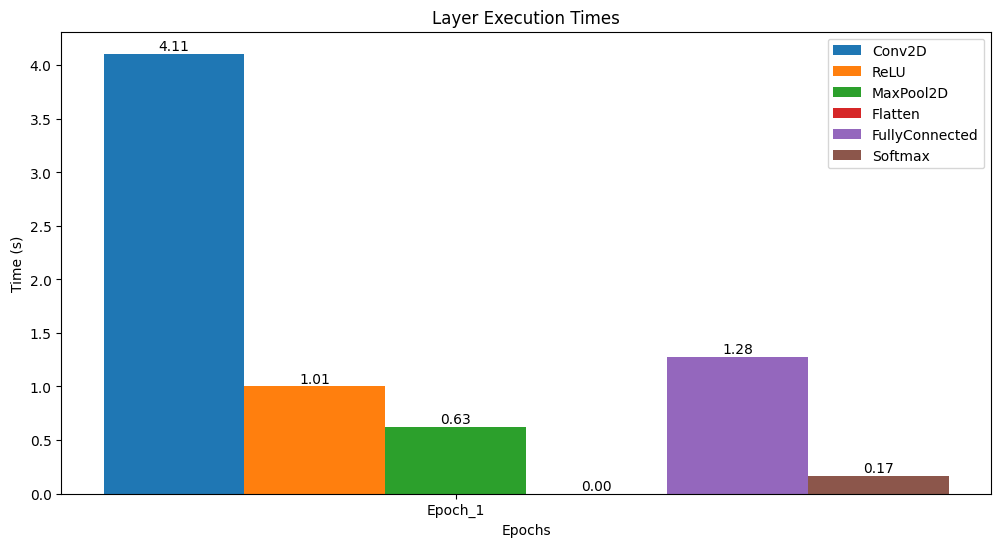

In [ ]:
func.plot_details(
    "Data/log/details_log_cuda_ver3_10.csv"
)

In [ ]:
model_2 = SimpleCNN_CUDA()
train_cuda(
    model_2,
    X_train,
    y_train_onehot,
    epochs=1,        # train thử 1 epoch
    learning_rate=0.001,
    momentum=0.9,
    lr_decay_factor=0.5,
    mb_size=64,
    log_filename="Data/log/training_log_cuda_ver3_50000.csv",
    detail_log_filename="Data/log/details_log_cuda_ver3_50000.csv"
)


📌 Sample 0
🧪 Conv output (before ReLU): mean=0.009263, std=0.166356, min=-0.660715, max=0.699392
🧪 Conv output (before ReLU): mean=-0.002146, std=0.171721, min=-0.789247, max=0.826173
🔍 After Block1: 0.06350019 0.103786096 | min: 0.0 | max: 0.82617295
🧪 Conv output (before ReLU): mean=0.010563, std=0.193133, min=-0.815578, max=0.827498
🧪 Conv output (before ReLU): mean=0.010765, std=0.261982, min=-0.945805, max=1.136046
🔍 After Block2: 0.10881412 0.15653314 | min: 0.0 | max: 1.1360464
🧪 Conv output (before ReLU): mean=0.000396, std=0.417718, min=-1.649538, max=1.253178
🧪 Conv output (before ReLU): mean=0.082104, std=0.725620, min=-2.458337, max=2.852790
🔍 After Block3: 0.32891122 0.45758668 | min: 0.0 | max: 2.8527904
🧊 MaxPool output - mean/std: 0.51145416 0.5367727
🧊 Zero count: 1173 / 4096
❌ Predict: 2, True: 7
👉 Kernel stats - mean: -0.0043561053 std: 0.058494266
👉 Kernel stats - mean: -0.0017235988 std: 0.057814766
👉 Kernel stats - mean: -2717.8142 std: 26360.273
👉 Kernel stats -

KeyboardInterrupt: 

In [ ]:
# func.plot_details(
#     "Data/log/details_log_cuda_ver3_50000.csv"
# )

### So sánh 1 epoch giữa Numba và Numba ver 2

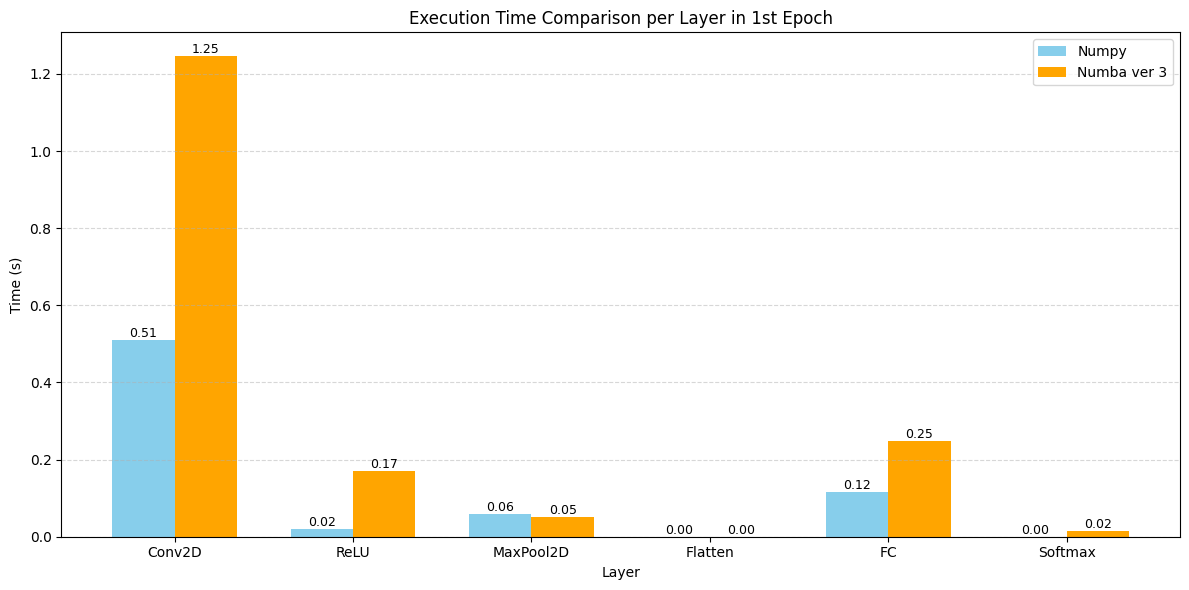

In [ ]:
func.plot_compare_details_customized(
    "Data/log/details_log_numpy_10.csv",
    "Data/log/details_log_cuda_ver3_10.csv",
    "Numpy",
    "Numba ver 3"
)